# Customer Segmentation — RFM + K-Means Clustering
**Group:** a1-g11 &nbsp;|&nbsp; **Project:** 01-ml-project

This notebook builds customer personas from one year of raw retail transactions using unsupervised
learning (K-Means clustering on RFM features). No labels are given upfront — the goal is to let the
data reveal the natural customer groups, then interpret and name them in business terms.


## Setup

We load the raw transaction-level dataset directly from the repo path. `random_state` is fixed
throughout for reproducibility.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(42)

df = pd.read_csv("01-ml-project/retail_transactions_segmentation.csv", parse_dates=["transaction_date"])
print(df.shape)
df.head()


(3663, 4)
   customer_id transaction_date  amount product_category
0         5206       2024-01-31  162.65          Fashion
1         5153       2024-07-03  389.85          Fashion
2         5102       2024-11-13  453.72    Home & Living
3         5073       2024-03-11  824.74      Electronics
4         5097       2024-12-28  181.74           Sports


## Point 1 — RFM Feature Table

The raw file is transaction-level (3,663 rows). We build a **customer-level** table (one row per
`customer_id`) with three engineered features:

- **Recency** — days between each customer's most recent purchase and a fixed reference date. We use
  **2024-12-30**, the maximum `transaction_date` in the dataset (i.e. "today" for this snapshot).
- **Frequency** — total number of transactions for that customer.
- **Monetary** — **total** spend per customer (we chose total over average, since it reflects overall
  customer value, not just typical basket size).


In [2]:
reference_date = df["transaction_date"].max()
print("Reference date used for Recency:", reference_date.date())

rfm = df.groupby("customer_id").agg(
    Recency=("transaction_date", lambda x: (reference_date - x.max()).days),
    Frequency=("transaction_date", "count"),
    Monetary=("amount", "sum"),
).reset_index()

print("RFM table shape:", rfm.shape)
print(rfm.head())


Reference date used for Recency: 2024-12-30
RFM table shape: (300, 4)
   customer_id  Recency  Frequency  Monetary
0         5001        1         16   5172.45
1         5002       22         18   6158.98
2         5003       36          3    654.12
3         5004        4         35  31050.88
4         5005       25         16   5700.91


## Point 2 — Scaling the Features

Recency (days), Frequency (transaction counts) and Monetary (currency) live on completely different
scales — Monetary values run into the tens of thousands while Frequency tops out around 35. K-Means
uses Euclidean distance, so without scaling, Monetary alone would dominate the distance calculation
and the other two features would barely matter. We standardize all three (zero mean, unit variance)
with `StandardScaler` before clustering.


In [3]:
feature_cols = ["Recency", "Frequency", "Monetary"]
X = rfm[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature means before scaling:", X.mean(axis=0).round(2))
print("Feature stds before scaling: ", X.std(axis=0).round(2))
print("Scaled feature means (~0):   ", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds (~1):    ", X_scaled.std(axis=0).round(3))


Feature means before scaling: [  53.66   12.21 6264.08]
Feature stds before scaling:  [  68.15   10.63 9643.69]
Scaled feature means (~0):    [-0. -0.  0.]
Scaled feature stds (~1):     [1. 1. 1.]


## Point 3 — Choosing k: Elbow Method + Silhouette Score

We sweep `k` from 2 to 10 and look at two diagnostics side by side:

- **Elbow method** — inertia (within-cluster sum of squares) vs. k. We look for the point where adding
  another cluster stops giving a big drop in inertia.
- **Silhouette score** — how well-separated the clusters are, averaged across all points (closer to 1
  is better).


k= 2   inertia=   394.21   silhouette=0.679
k= 3   inertia=   183.03   silhouette=0.678
k= 4   inertia=    93.39   silhouette=0.570
k= 5   inertia=    71.41   silhouette=0.523
k= 6   inertia=    50.34   silhouette=0.519
k= 7   inertia=    41.13   silhouette=0.463
k= 8   inertia=    30.22   silhouette=0.481
k= 9   inertia=    24.12   silhouette=0.482
k=10   inertia=    21.07   silhouette=0.476


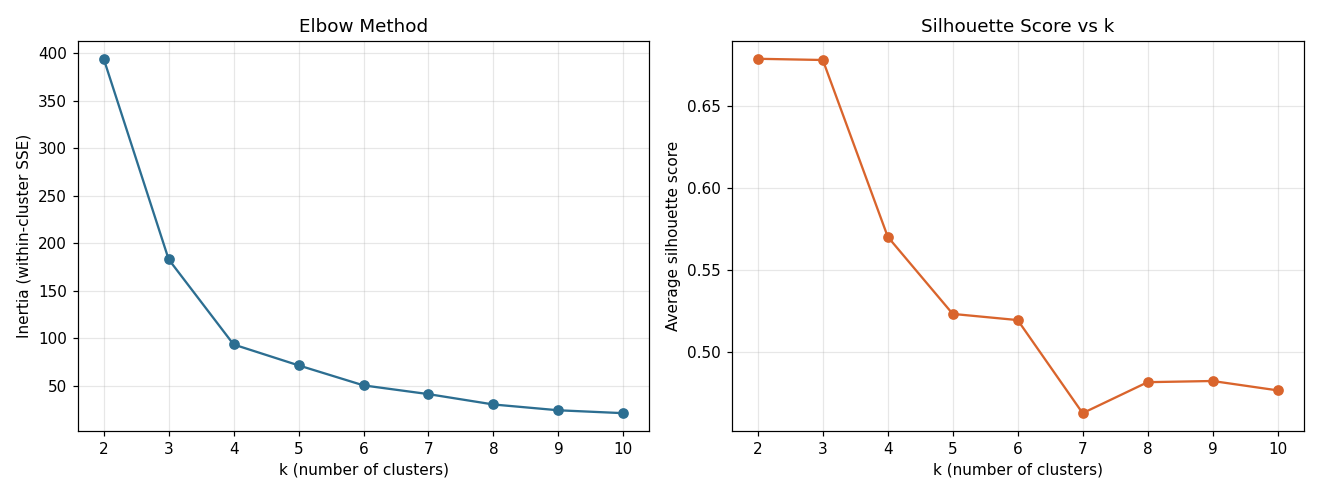

In [4]:
ks = list(range(2, 11))
inertias, sil_scores = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

for k, i, s in zip(ks, inertias, sil_scores):
    print(f"k={k:2d}   inertia={i:9.2f}   silhouette={s:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ks, inertias, marker="o", color="#2C6E91")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Method")
axes[0].grid(alpha=0.3)

axes[1].plot(ks, sil_scores, marker="o", color="#D9642C")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Average silhouette score")
axes[1].set_title("Silhouette Score vs k")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=110)
plt.show()


**Choice of k = 4.** The silhouette score is highest at k=2 (0.68) and nearly as high at k=3
(0.68), but those are too coarse — k=2 essentially only separates the handful of big spenders from
everyone else, and doesn't distinguish "loyal regulars" from "dormant" customers, which matters for
a marketing action plan. The elbow plot keeps dropping sharply through k=3 and k=4 (183 → 93) and then
flattens out from k=5 onward (each further split buys very little extra separation). At k=4 the
silhouette score (0.57) is still solidly good, and — checked against the actual cluster averages below
— it produces four groups with clearly distinct Recency/Frequency/Monetary profiles that map cleanly
onto real business personas. So we pick **k=4** as the point where the elbow flattens and the clusters
still make interpretable business sense.


## Point 4 — Fit K-Means with k=4

In [5]:
CHOSEN_K = 4
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

rfm["cluster"] = labels
print("Chosen k:", CHOSEN_K)
print("Final inertia:", round(kmeans.inertia_, 2))
print(rfm["cluster"].value_counts().sort_index())
rfm.head()


Chosen k: 4
Final inertia: 93.39
cluster
0    111
1     40
2     21
3    128
Name: count, dtype: int64
   customer_id  Recency  Frequency  Monetary  cluster
0         5001        1         16   5172.45        3
1         5002       22         18   6158.98        3
2         5003       36          3    654.12        0
3         5004        4         35  31050.88        1
4         5005       25         16   5700.91        3


## Point 5 — PCA Visualization

We reduce the three scaled RFM features to 2 principal components and plot the clusters in that space,
colour-coded by cluster label.


Explained variance ratio (PC1, PC2): [0.75  0.237]
Total variance captured by 2 components: 98.7 %


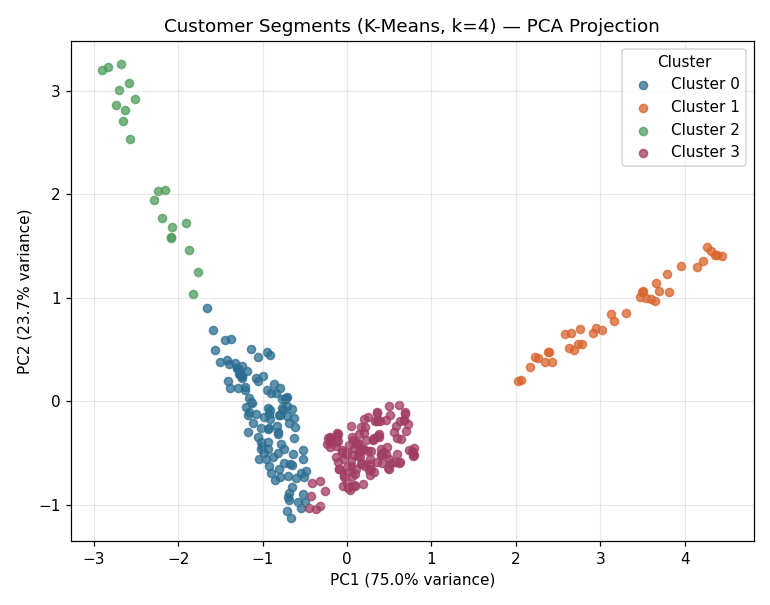

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained_var_ratio = pca.explained_variance_ratio_
print("Explained variance ratio (PC1, PC2):", explained_var_ratio.round(3))
print("Total variance captured by 2 components:", round(explained_var_ratio.sum() * 100, 1), "%")

plt.figure(figsize=(7, 5.5))
palette = ["#2C6E91", "#D9642C", "#4E9C5C", "#A13D63"]
for c in sorted(rfm["cluster"].unique()):
    mask = rfm["cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=28, alpha=0.75,
                label=f"Cluster {c}", color=palette[c % len(palette)])
plt.xlabel(f"PC1 ({explained_var_ratio[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var_ratio[1]*100:.1f}% variance)")
plt.title("Customer Segments (K-Means, k=4) — PCA Projection")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=110)
plt.show()


## Point 6 — Naming the Personas

The table below shows the mean Recency / Frequency / Monetary per cluster — this is the evidence
behind each persona name.


In [7]:
persona_table = rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
persona_table["n_customers"] = rfm["cluster"].value_counts().sort_index()
persona_table


         Recency  Frequency  Monetary  n_customers
cluster                                           
0           70.6        4.2     752.5          111
1            7.4       35.0   29683.6           40
2          262.4        2.1     320.5           21
3           19.2       13.7    4700.2          128


Based on the table above:

- **Cluster 1 — "VIP / Champions"** (40 customers, avg. Recency ≈ 7 days, Frequency ≈ 35, Monetary ≈ EGP 29,684).
  These are the most valuable customers by a wide margin: they buy constantly and recently, and their
  total spend dwarfs every other group. The business should protect this group above all — early access
  to new products, a dedicated loyalty tier, and personal outreach if their activity ever slows down.

- **Cluster 3 — "Loyal Regulars"** (128 customers, avg. Recency ≈ 19 days, Frequency ≈ 14, Monetary ≈ EGP 4,700).
  The largest segment: solid, consistent buyers who purchase often enough and recently enough to be
  reliable revenue. They are the best candidates for upselling and cross-category promotions to nudge
  them toward VIP status.

- **Cluster 0 — "At-Risk"** (111 customers, avg. Recency ≈ 71 days, Frequency ≈ 4, Monetary ≈ EGP 753).
  Their last purchase was over two months ago and they buy rarely — engagement is fading. This is the
  group where a well-timed win-back campaign (discount code, "we miss you" email) has the best chance
  of paying off before they slide into Dormant.

- **Cluster 2 — "Dormant"** (21 customers, avg. Recency ≈ 262 days, Frequency ≈ 2, Monetary ≈ EGP 320).
  Barely active — average last purchase was nearly nine months before the reference date, with very few
  transactions and minimal spend. Aggressive win-back offers have low expected ROI here; the more
  efficient move is to deprioritize regular marketing spend on this group and only re-engage with a
  low-cost seasonal reactivation email.

*(Note: the numeric cluster labels K-Means assigns — 0, 1, 2, 3 — are arbitrary and can change between
runs. What matters is that each persona name is grounded in that cluster's own Recency/Frequency/Monetary
averages, shown in the table above.)*
